In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing

import urllib.request

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import regularizers
from keras.optimizers import Adam


np.random.seed(41)
tf.random.set_seed(41)


# Questão 1

## Definindo a função f(x)

In [4]:
def f(x):
    return (10*x**5) + (5*x**4) + (2*x**3) - (0.5*x**2) + (3*x + 2)

## Gerando os dados de treino e teste

In [5]:
X = np.linspace(0, 5, 2000).reshape(-1, 1)
y = f(X)

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

#### Normalizando os dados

In [7]:
normalizador = MinMaxScaler()
X_treino = normalizador.fit_transform(X_treino)
X_teste = normalizador.transform(X_teste)

## Arquitetura da Rede Neural

In [8]:
# Função que calcula a quantidade máxima de neurônios na camada oculta da rede neural
def num_max_neuronio(X, d):
    CT = len(X)
    return int((CT - 10)/(10 * (d + 2)))

num_max_neuronio(X, 1) 

66

In [9]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.01), metrics=['mae'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
history = model.fit(X_treino, y_treino,
            epochs=50,
            batch_size=32,
            validation_data = (X_teste, y_teste),
            verbose=0)

## Avaliando no conjunto de Teste

In [11]:
resultado = model.evaluate(X_teste, y_teste)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 840.7615 - mae: 22.2685


## Função Real x Função Aproximada

In [12]:
history_df = pd.DataFrame(history.history)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


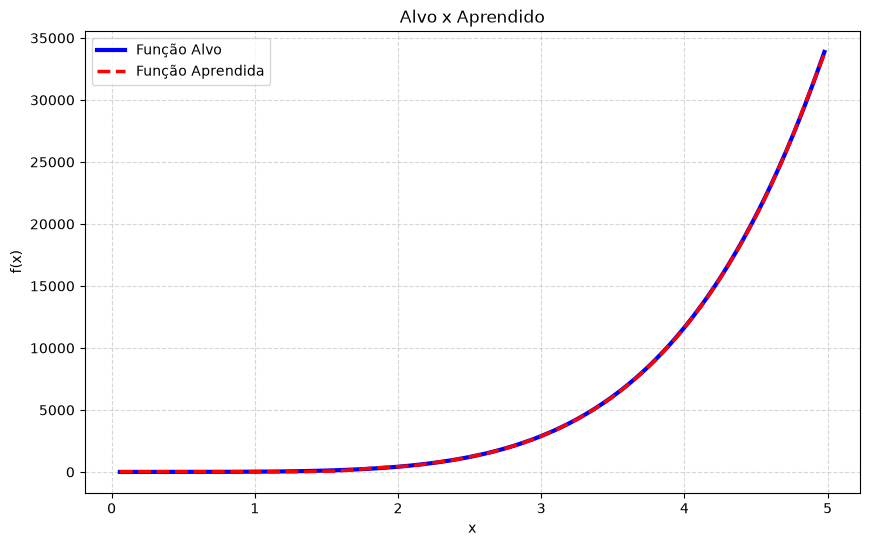

In [13]:
y_predito = model.predict(X_teste)
X_teste_original = normalizador.inverse_transform(X_teste)

indices_ordenados = np.argsort(X_teste_original, axis=0).flatten()

X_plot = X_teste_original[indices_ordenados]
y_real_plot = y_teste[indices_ordenados]
y_predito_plot = y_predito[indices_ordenados]

plt.figure(figsize=(10, 6))
plt.plot(X_plot, y_real_plot, label='Função Alvo', color='blue', linewidth=3)
plt.plot(X_plot, y_predito_plot, label='Função Aprendida', color='red', linestyle='dashed', linewidth=2.5)

plt.title('Alvo x Aprendido')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Curva de erro no treinamento

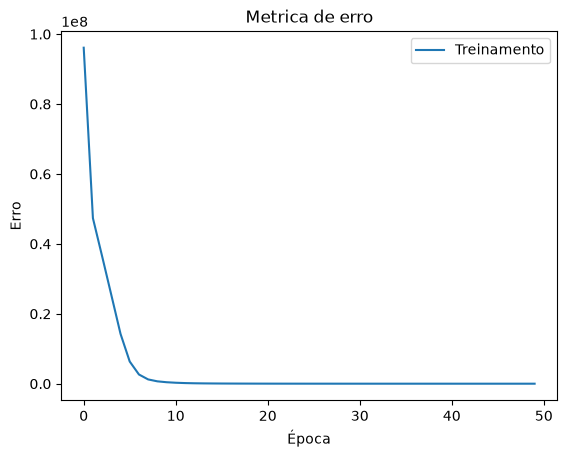

In [14]:
plt.plot(history_df['loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento'])
plt.show()


## Curva de erro no teste

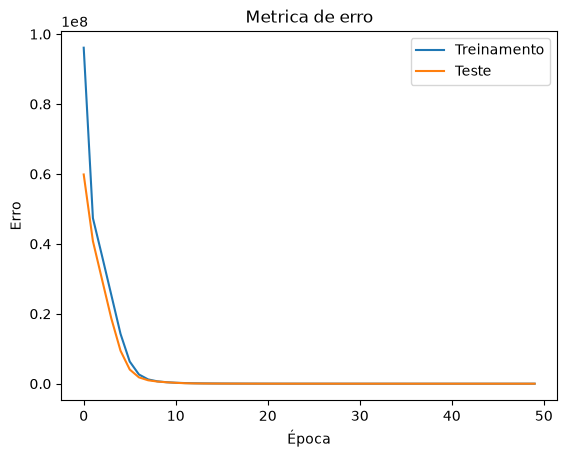

In [15]:
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Teste'])
plt.show()


## Métricas de avaliação

In [16]:
mse = resultado[0]
rmse = np.sqrt(resultado[0])
mae = resultado[1]
amplitude = f(5) - f(0)

nrmse = rmse / amplitude

print(f"MSE: {mse:.4f}\n"
      f"RMSE: {rmse:.4f}\n"  \
      f"NRMSE: {nrmse:.4f}"\
      f"\nMAE: {mae:.4f}")

MSE: 840.7615
RMSE: 28.9959
NRMSE: 0.0008
MAE: 22.2685


## California Housing Dataset

In [17]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(data = california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Não temos valores nulos, todas as colunas estão com os tipos numéricos.

In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Dicionário de Dados: California Housing (1990)

Cada linha deste dataset não representa uma casa individual, mas sim um **Grupo de Quarteirões** (block group), que é a menor unidade geográfica do Censo dos EUA (abrigando de 600 a 3.000 pessoas).

| Variável (Atributo) | Descrição | Unidade / Escala | Tipo |
| :--- | :--- | :--- | :--- |
| **`MedInc`** | Renda mediana das famílias do quarteirão. | Dezenas de milhares de US$ *(Ex: 8.3 = $83.000/ano)* | `float64` |
| **`HouseAge`** | Idade mediana das casas do quarteirão. | Anos | `float64` |
| **`AveRooms`** | Número médio de cômodos totais por domicílio. | Quantidade de cômodos | `float64` |
| **`AveBedrms`** | Número médio de quartos de dormir por domicílio. | Quantidade de quartos | `float64` |
| **`Population`** | População total que reside no quarteirão. | Número de Pessoas | `float64` |
| **`AveOccup`** | Número médio de ocupantes (moradores) por casa. | Número de Pessoas | `float64` |
| **`Latitude`** | Coordenada de latitude do quarteirão. | Graus Geográficos | `float64` |
| **`Longitude`** | Coordenada de longitude do quarteirão. | Graus Geográficos | `float64` |
| **`MedHouseVal`** | Valor mediano dos imóveis no quarteirão. | Centenas de milhares de US$ *(Ex: 4.5 = $450.000)* | `float64` |


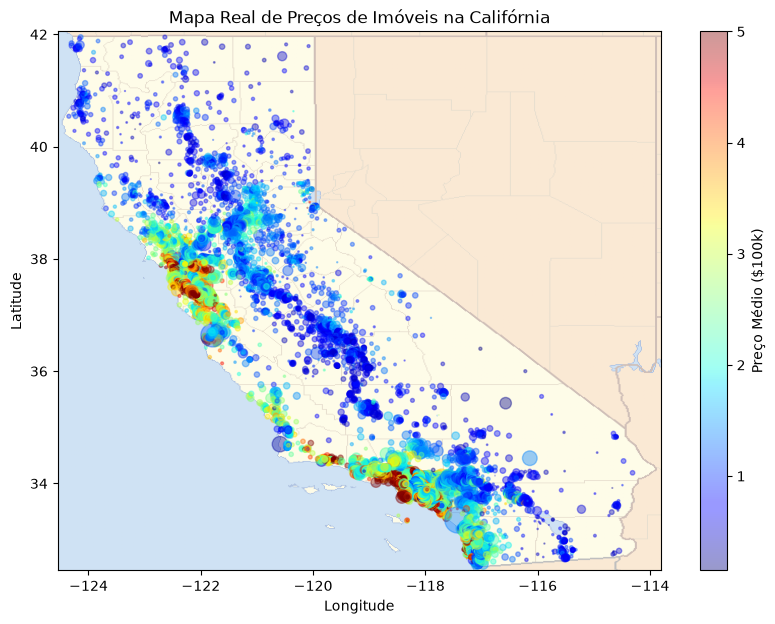

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/images/end_to_end_project/california.png"
urllib.request.urlretrieve(url, "img/california.png")
mapa_img = mpimg.imread("img/california.png")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(x=df['Longitude'], y=df['Latitude'], 
                      alpha=0.4, 
                      s=df['Population']/100, 
                      c=df['MedHouseVal'], 
                      cmap=plt.get_cmap("jet"))

plt.imshow(mapa_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)

plt.colorbar(scatter, label='Preço Médio ($100k)')
plt.title('Mapa Real de Preços de Imóveis na Califórnia')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

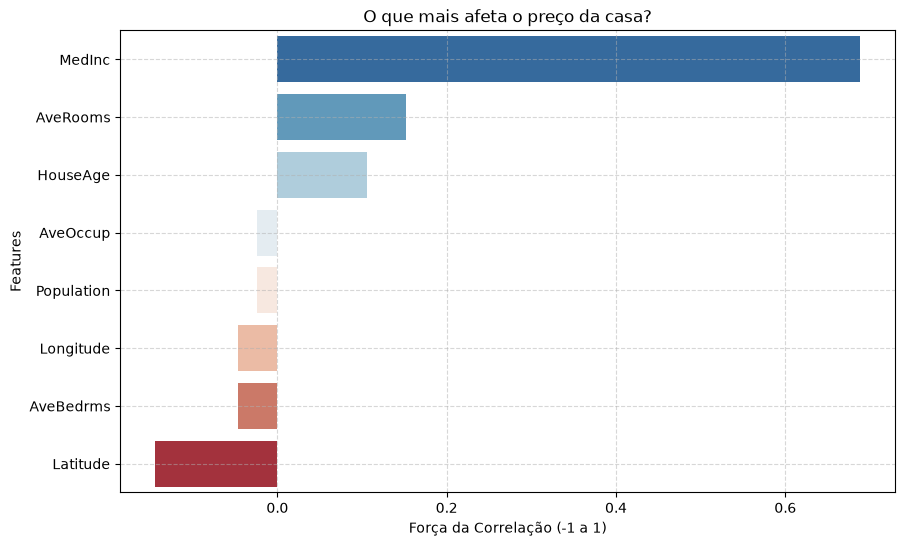

In [23]:
plt.figure(figsize=(10, 6))

# Calcula a correlação, pega só a coluna do alvo, remove a correlação do alvo com ele mesmo e ordena
correlacao_alvo = df.corr()[['MedHouseVal']].drop('MedHouseVal').sort_values(by='MedHouseVal', ascending=False)

sns.barplot(x=correlacao_alvo['MedHouseVal'], y =correlacao_alvo.index, hue =correlacao_alvo.index, palette='RdBu_r', legend = False)

plt.title('O que mais afeta o preço da casa?')
plt.xlabel('Força da Correlação (-1 a 1)')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

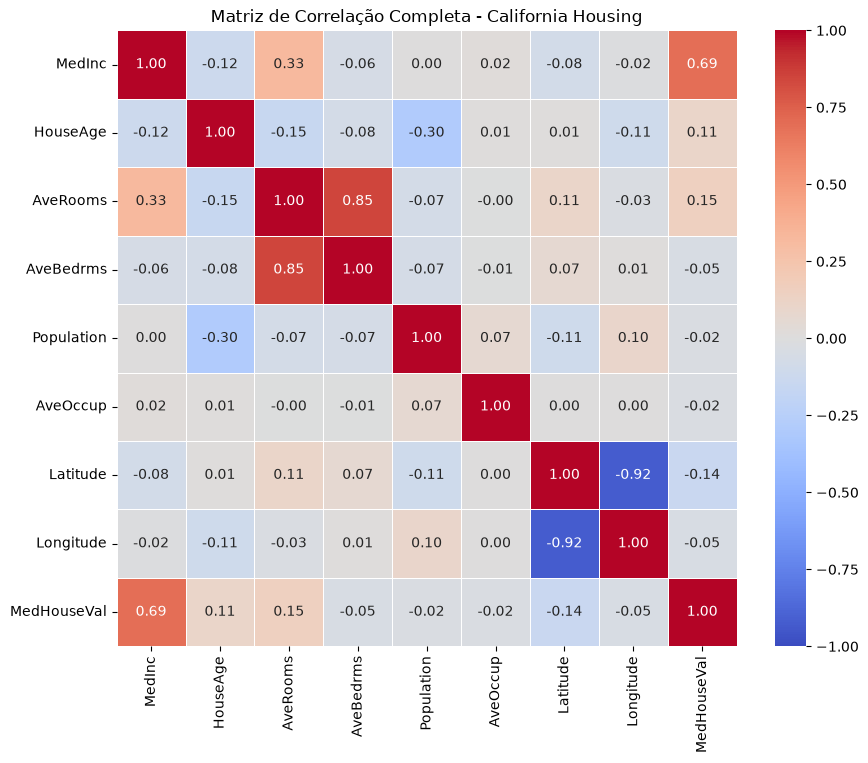

In [56]:
# Matriz de Correlação de TODAS as variáveis entre si
plt.figure(figsize=(10, 8))
# O comando df.corr() calcula a correlação de Pearson (tudo contra tudo)
matriz_correlacao = df.corr()
# Desenhando o Mapa de Calor
# annot=True exibe os números, cmap é a paleta de cores (coolwarm = azul pro negativo, vermelho pro positivo)
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação Completa - California Housing")
plt.show()


As features AveRooms e AveBedrms tem muita correlação entre si, podemos remover uma delas.

In [57]:
df.drop(columns=['AveRooms'], inplace = True)

df.columns

Index(['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup', 'Latitude',
       'Longitude', 'MedHouseVal'],
      dtype='str')

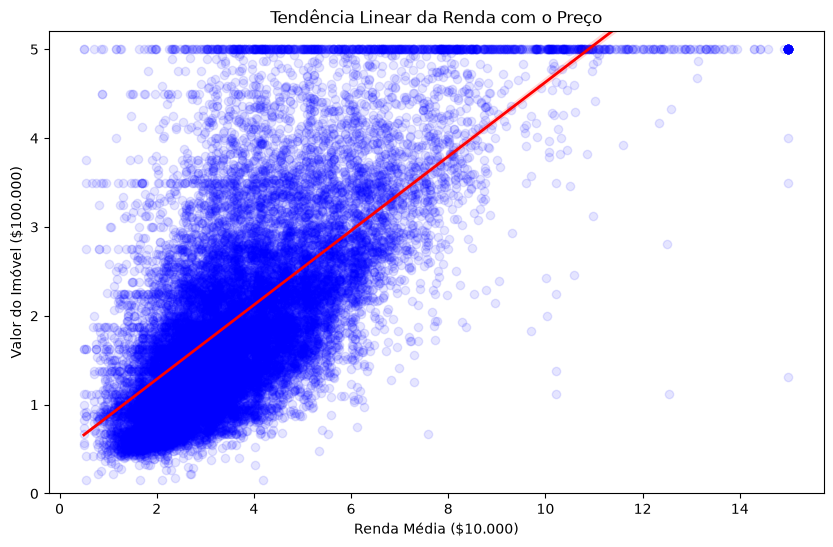

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df['MedInc'], y=df['MedHouseVal'], 
            scatter_kws={'alpha':0.1, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2})   

plt.title('Tendência Linear da Renda com o Preço')
plt.xlabel('Renda Média ($10.000)')
plt.ylabel('Valor do Imóvel ($100.000)')
plt.ylim(0, 5.2)
plt.show()

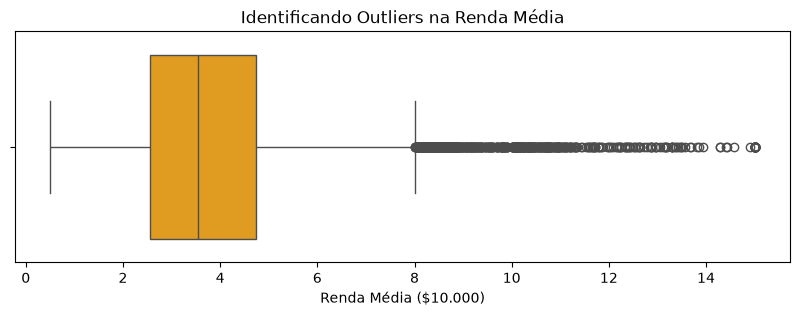

In [ ]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df['MedInc'], color='orange')

plt.title('Identificando Outliers na Renda Média')
plt.xlabel('Renda Média ($10.000)')
plt.show()

Os outliers nesse caso não parece ruído, há a possibilidade de pessoas que recebam esse salário

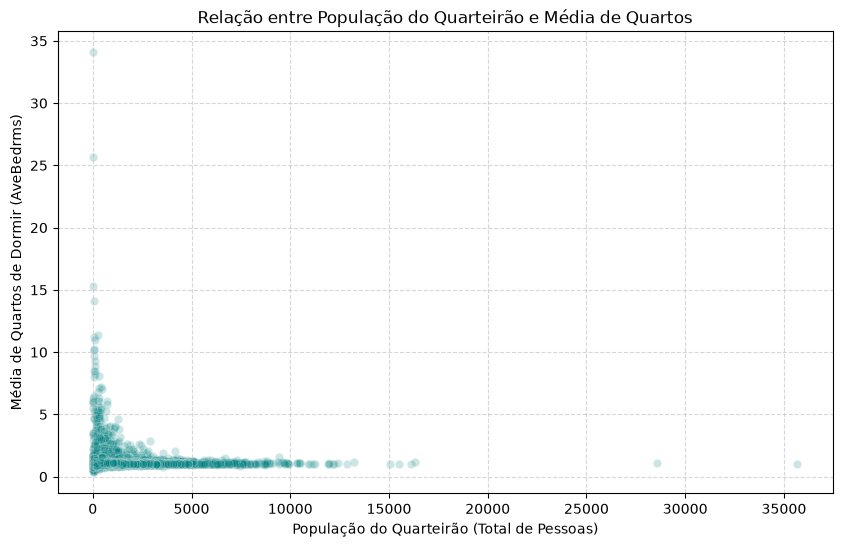

In [ ]:
# Gráfico de Dispersão: População vs Média de Quartos
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['Population'], y=df['AveBedrms'], 
                alpha=0.2, color='teal')

plt.title('Relação entre População do Quarteirão e Média de Quartos')
plt.xlabel('População do Quarteirão (Total de Pessoas)')
plt.ylabel('Média de Quartos de Dormir (AveBedrms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Essas colunas apresentam outliers muito isolados, serão removidos

In [69]:
df_sem_outliers = df[(df['Population'] < 15000) & (df['AveBedrms'] < 10)]

## Normalizando os dados

In [70]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

In [76]:
X_treino_cal, X_teste_cal, y_treino_cal, y_teste_cal = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
normalizador = MinMaxScaler()
X_treino = normalizador.fit_transform(X_treino_cal)
X_teste = normalizador.transform(X_teste_cal)

## Arquitetura da rede neural

In [84]:
model = Sequential()

model.add(Input(shape=(X_treino_cal.shape[1],)))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,785 (26.50 KB)

 Trainable params: 6,785 (26.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [85]:
history_cal = model.fit(X_treino, y_treino,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            verbose=1)

Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - loss: 0.7526 - mae: 0.6395 - val_loss: 0.5769 - val_mae: 0.5583
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - loss: 0.5380 - mae: 0.5356 - val_loss: 0.5465 - val_mae: 0.5505
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - loss: 0.4975 - mae: 0.5121 - val_loss: 0.5247 - val_mae: 0.5383
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.4701 - mae: 0.4949 - val_loss: 0.5034 - val_mae: 0.5204
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.4533 - mae: 0.4842 - val_loss: 0.4931 - val_mae: 0.5137
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - loss: 0.4423 - mae: 0.4767 - val_loss: 0.4875 - val_mae: 0.5098
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - loss: 0.4350 - mae: 0.4712 - val_loss: 0.4854 - val_mae: 0.5099
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - loss: 0.4291 - mae: 0.4673 - val_loss: 0.4847 - val_mae: 0.5098
Epoch 9/200
413/413 ━━━━━━━━━━━━

In [86]:
history_df_cal = pd.DataFrame(history_cal.history)

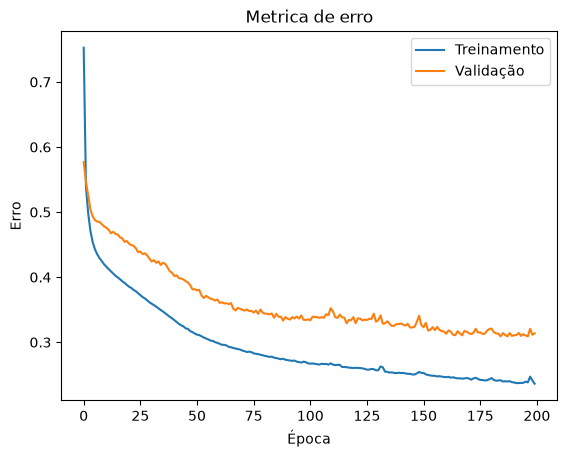

In [94]:
plt.plot(history_df_cal['loss'])
plt.plot(history_df_cal['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()


Pelas métricas de erro, a rede neural teve overfitting

In [ ]:
model = Sequential()

model.add(Input(shape=(X_treino.shape[1],)))

model.add(Dense(128, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(128, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(64, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(32, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, kernel_initializer='he_normal', activation='linear'))

model.compile(loss='mse', optimizer=Adam(learning_rate=0.0001), metrics=['mae'])

print(model.summary())

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,905 (109.00 KB)

 Trainable params: 27,905 (109.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [117]:
history_cal_1 = model.fit(X_treino, y_treino,
            epochs=10000,
            batch_size=128,
            validation_split=0.2,
            verbose=1)

Epoch 1/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.9202 - mae: 1.1428 - val_loss: 1.9796 - val_mae: 0.8314
Epoch 2/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 2.3465 - mae: 0.9980 - val_loss: 1.7826 - val_mae: 0.7596
Epoch 3/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 2.1021 - mae: 0.9231 - val_loss: 1.6240 - val_mae: 0.6960
Epoch 4/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - loss: 1.9170 - mae: 0.8602 - val_loss: 1.5558 - val_mae: 0.6608
Epoch 5/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - loss: 1.8274 - mae: 0.8291 - val_loss: 1.5225 - val_mae: 0.6459
Epoch 6/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - loss: 1.7515 - mae: 0.7988 - val_loss: 1.5334 - val_mae: 0.6536
Epoch 7/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 1.6806 - mae: 0.7782 - val_loss: 1.4881 - val_mae: 0.6387
Epoch 8/10000
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - loss: 1.6387 - mae: 0.7669 - val_loss: 1.4704 - val_mae: 0.6356
Epoch 9/10000
104/

In [118]:
history_df_cal_1 = pd.DataFrame(history_cal_1.history)

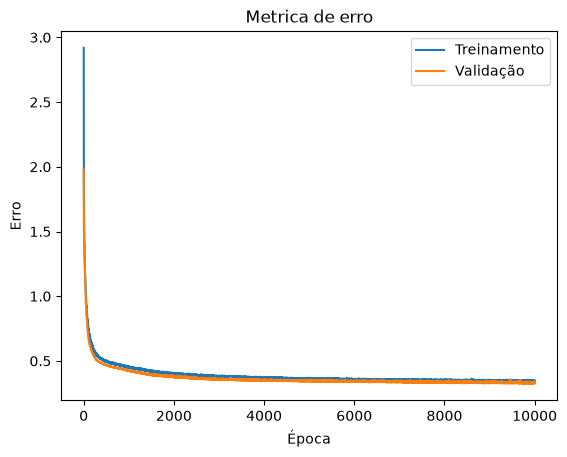

In [119]:
plt.plot(history_df_cal_1['loss'])
plt.plot(history_df_cal_1['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.show()


In [121]:
history_df_cal_1['loss'].min()

np.float64(0.3352166712284088)

In [120]:
np.sqrt(history_df_cal_1['loss'].min())

np.float64(0.5789789903169275)

## Prevendo os valores do Teste

In [122]:
resultado = model.evaluate(X_teste, y_teste)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.3260 - mae: 0.3555


In [125]:
mse = resultado[0]
rmse = np.sqrt(resultado[0])
mae = resultado[1]

print(f"MSE: {mse:.4f}\n"
      f"RMSE: {rmse:.4f}\n"  \
      f"MAE: {mae:.4f}")

MSE: 0.3260
RMSE: 0.5710
MAE: 0.3555


## Comparação do valor previsto para o valor Real

## Salvando a rede neural com os pesos aprendidos

In [127]:
import joblib

model.save('modelo_california.keras')
joblib.dump(normalizador, 'normalizador_california.pkl')

['normalizador_california.pkl']